# Clustering based Course Recommender System

In this section I am going to use K-Mean clustering and DBSCAN to group users with similar learning interests. 


## Prepare and setup lab environment

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [2]:
# initiate the random state
rs = 42

In [3]:
# Load the user profile dataset
profile_df = pd.read_csv("user_profile.csv")
profile_df.head(2)

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,2,52.0,14.0,6.0,43.0,3.0,33.0,0.0,29.0,41.0,2.0,18.0,34.0,9.0,6.0
1,4,40.0,2.0,4.0,28.0,0.0,14.0,0.0,20.0,24.0,0.0,6.0,6.0,0.0,2.0


In [4]:
profile_df.shape

(33901, 15)

In [5]:
# List the features
feature_names = list(profile_df.columns[1:])
feature_names

['Database',
 'Python',
 'CloudComputing',
 'DataAnalysis',
 'Containers',
 'MachineLearning',
 'ComputerVision',
 'DataScience',
 'BigData',
 'Chatbot',
 'R',
 'BackendDev',
 'FrontendDev',
 'Blockchain']

In [6]:
# Describe the users dataset
profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000,33901.000000
mean,1.064064e+06,5.518569,3.493791,2.307100,3.624701,0.998938,3.048022,0.001770,5.087343,4.750450,0.462995,1.017433,2.269461,0.315802,0.986844
std,4.972578e+05,7.611941,4.227254,3.841858,4.760135,2.351764,4.624004,0.072846,5.230697,7.216228,1.055186,2.342532,4.310752,1.363462,1.950585
min,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.813480e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.043907e+06,3.000000,3.000000,0.000000,3.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.451159e+06,9.000000,6.000000,3.000000,6.000000,0.000000,3.000000,0.000000,9.000000,6.000000,0.000000,0.000000,3.000000,0.000000,2.000000
max,2.103039e+06,63.000000,18.000000,38.000000,48.000000,15.000000,39.000000,3.000000,32.000000,54.000000,6.000000,18.000000,54.000000,15.000000,12.000000


The original user profile feature vector is not normalized, which may cause issues when performing clustering and Principal component analysis (PCA), therefor we standardize the data.

In [7]:
# Use StandardScaler to make each feature with mean 0, standard deviation 1
# Instantiating a StandardScaler object
scaler = StandardScaler()

# Standardizing the selected features (feature_names) in the user_profile_df DataFrame
profile_df[feature_names] = scaler.fit_transform(profile_df[feature_names])

# Printing the mean and standard deviation of the standardized features
print("mean {} and standard deviation{}  ".format(profile_df[feature_names].mean(), profile_df[feature_names].std()))

mean Database          -3.353495e-17
Python            -5.700942e-17
CloudComputing    -3.521170e-17
DataAnalysis      -7.671120e-17
Containers         3.353495e-18
MachineLearning    3.688845e-17
ComputerVision    -1.509073e-17
DataScience       -1.676748e-17
BigData            6.706990e-17
Chatbot           -6.874665e-17
R                  4.233788e-17
BackendDev         1.383317e-17
FrontendDev        5.051202e-17
Blockchain        -5.281755e-17
dtype: float64 and standard deviationDatabase           1.000015
Python             1.000015
CloudComputing     1.000015
DataAnalysis       1.000015
Containers         1.000015
MachineLearning    1.000015
ComputerVision     1.000015
DataScience        1.000015
BigData            1.000015
Chatbot            1.000015
R                  1.000015
BackendDev         1.000015
FrontendDev        1.000015
Blockchain         1.000015
dtype: float64  


In [8]:
profile_df.describe()

,user,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
count,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04,3.390100e+04
mean,1.064064e+06,-3.353495e-17,-5.700942e-17,-3.521170e-17,-7.671120e-17,3.353495e-18,3.688845e-17,-1.509073e-17,-1.676748e-17,6.706990e-17,-6.874665e-17,4.233788e-17,1.383317e-17,5.051202e-17,-5.281755e-17
std,4.972578e+05,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00,1.000015e+00
min,2.000000e+00,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
25%,6.813480e+05,-7.249991e-01,-8.265040e-01,-6.005256e-01,-7.614816e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-9.726080e-01,-6.583107e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
50%,1.043907e+06,-3.308757e-01,-1.168130e-01,-6.005256e-01,-1.312380e-01,-4.247674e-01,-6.591835e-01,-2.429612e-02,-3.990622e-01,-3.811535e-01,-4.387873e-01,-4.343370e-01,-5.264730e-01,-2.316212e-01,-5.059295e-01
75%,1.451159e+06,4.573712e-01,5.928781e-01,1.803581e-01,4.990056e-01,-4.247674e-01,-1.038556e-02,-2.429612e-02,7.480294e-01,1.731609e-01,-4.387873e-01,-4.343370e-01,1.694715e-01,-2.316212e-01,5.194189e-01
max,2.103039e+06,7.551593e+00,3.431642e+00,9.290667e+00,9.322416e+00,5.953517e+00,7.775190e+00,4.115884e+01,5.145214e+00,6.824934e+00,5.247500e+00,7.249771e+00,1.200053e+01,1.076995e+01,5.646161e+00


The normalized user profile features are: 

In [9]:
features = profile_df.loc[:, profile_df.columns != 'user']
features.head(2)

,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,6.106474,2.485388,0.961242,8.272010,0.850889,6.477594,-0.024296,4.571668,5.023412,1.456642,7.249771,7.360899,6.369323,2.570116
1,4.529980,-0.353377,0.440653,5.120792,-0.424767,2.368540,-0.024296,2.851031,2.667576,-0.438787,2.127032,0.865416,-0.231621,0.519419


In [10]:
user_ids = profile_df.loc[:, profile_df.columns == 'user']
user_ids.head(2)

,user
0,2
1,4


### TASK: Perform K-means clustering algorithm on the user profile feature vectors
- With the user profile dataset ready, you need to use the `KMeans` class provided by scikit-learn library to perform clustering on the user profile feature vectors. 
- For `KMeans` algorithm, one important hyperparameter is the number of clusters `n_cluster`, and a good way to find the optimized `n_cluster` is using to grid search a list of candidates and find the one with the best or optimized clustering evaluation metrics such as minimal `sum of squared distance`:

- Find an optimized number of neighors k from a candidate list such as list_k = list(range(1, 30))

   user  Database  Python  CloudComputing  DataAnalysis  Containers  \
0     2      52.0    14.0             6.0          43.0         3.0   
1     4      40.0     2.0             4.0          28.0         0.0   
2     5      24.0     8.0            18.0          24.0         0.0   
3     7       2.0     0.0             0.0           2.0         0.0   
4     8       6.0     0.0             0.0           4.0         0.0   

   MachineLearning  ComputerVision  DataScience  BigData  Chatbot     R  \
0             33.0             0.0         29.0     41.0      2.0  18.0   
1             14.0             0.0         20.0     24.0      0.0   6.0   
2             30.0             0.0         22.0     14.0      2.0  14.0   
3              0.0             0.0          0.0      2.0      0.0   0.0   
4              0.0             0.0          0.0      6.0      0.0   2.0   

   BackendDev  FrontendDev  Blockchain  
0        34.0          9.0         6.0  
1         6.0          0.0         2.0  

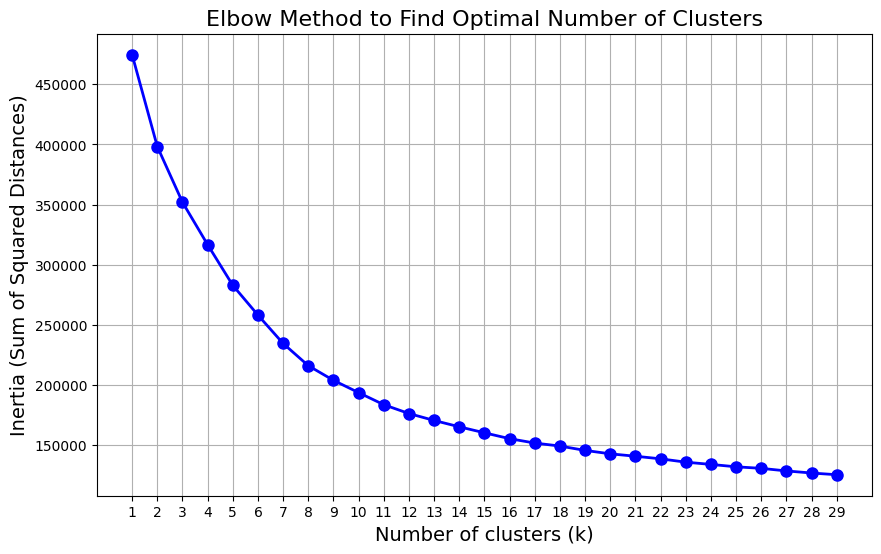

Optimal number of clusters (k): 8
   user  cluster
0     2        2
1     4        2
2     5        2
3     7        7
4     8        7


In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load user profile dataset
profile_df = pd.read_csv("user_profile.csv")

# Inspect data briefly
print(profile_df.head())

# Drop non-feature columns (e.g., user ID)
X = profile_df.drop(columns=['user'])

# Scale the features (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define candidate number of clusters (k)
list_k = list(range(1, 30))
inertia = []

# Run K-means for each candidate k and store inertia
for k in list_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(list_k, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=14)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=14)
plt.title('Elbow Method to Find Optimal Number of Clusters', fontsize=16)
plt.xticks(list_k)
plt.grid(True)
plt.show()

# Find the optimal number of clusters programmatically (optional but useful)
from kneed import KneeLocator
knee = KneeLocator(list_k, inertia, curve='convex', direction='decreasing')
optimal_k = knee.knee
print(f"Optimal number of clusters (k): {optimal_k}")

# Final K-means clustering with optimal_k
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
profile_df['cluster'] = final_kmeans.fit_predict(X_scaled)

# Display resulting clusters
print(profile_df[['user', 'cluster']].head())


From the elbow plot, you should visualy identify the point where the metric starting to be flatten, which indicates the optimized number of clusters.

In [12]:
cluster_labels = [None] * len(user_ids)


_TODO: Apply KMeans() on the features with optimized n_cluster parameter after model fitting, you can find output cluster labels in `model.labels_` attribute_


In [13]:
from sklearn.cluster import KMeans

# Assuming 'optimal_k' was found previously using the elbow method
# and 'X_scaled' is your scaled feature matrix

# Initialize KMeans with optimized cluster count
model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the model on the scaled features
model.fit(X_scaled)

# Get the cluster labels for each sample
cluster_labels = model.labels_

# Optionally add cluster labels back to your dataframe
profile_df['cluster'] = cluster_labels

# Show first few cluster assignments
print(profile_df[['user', 'cluster']].head())


   user  cluster
0     2        2
1     4        2
2     5        2
3     7        7
4     8        7


Understanding in which cluster each user belongs means I have created learning communities and learners within each community share very similar learning interests.

### TASK: Apply PCA on user profile feature vectors to reduce dimensions

Applied `KMeans` on the original user profile feature vectors which have 14 original features (the course genres)

In [14]:
# Extracting features from the user_profile_df DataFrame, excluding the 'user' column
features = profile_df.loc[:, profile_df.columns != 'user']

# Extracting user IDs from the user_profile_df DataFrame
user_ids = profile_df.loc[:, profile_df.columns == 'user']

# Creating a list of feature names by excluding the 'user' column name
feature_names = list(profile_df.columns[1:])

print(f"There are {len(feature_names)} features for each user profile.")

There are 15 features for each user profile.


Plotting the covariance matrix of the user profile feature vectors with 14 features, we can observe that some features are actually correlated:

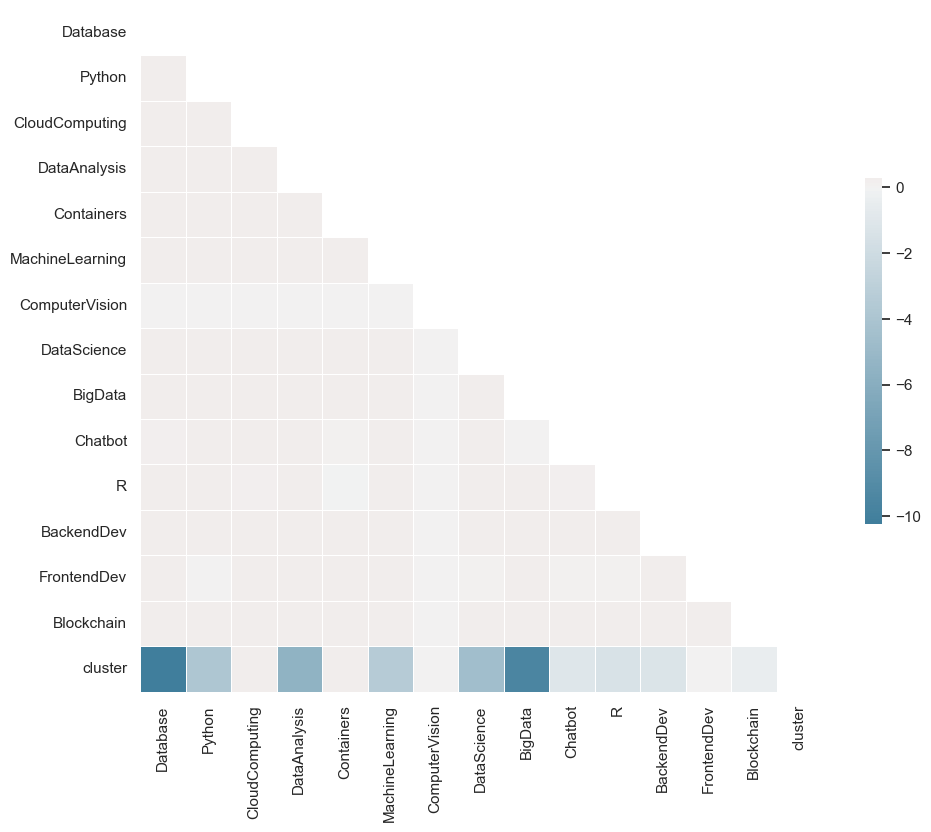

In [15]:
sns.set_theme(style="white")

# Compute the correlation matrix
corr = features.cov()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


plt.show()

PCA

Optimal number of PCA components (≥90% variance explained): 9


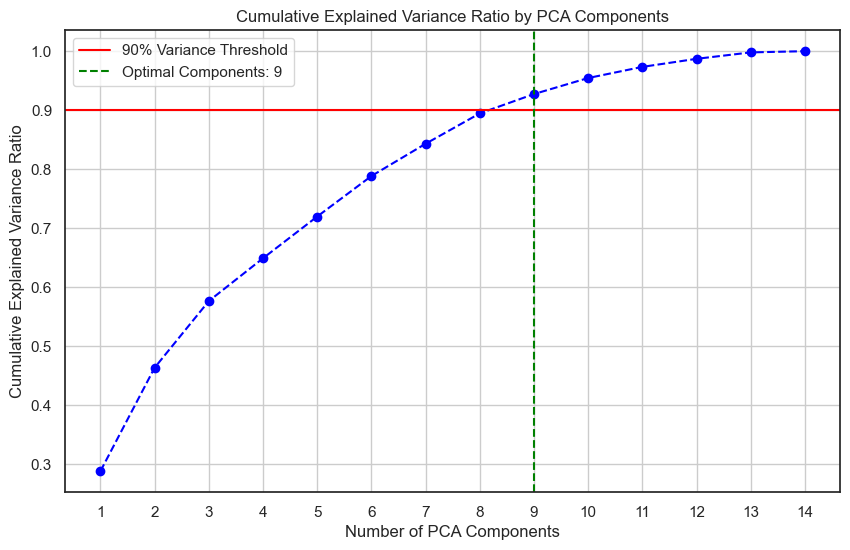

Shape before PCA: (33901, 14)
Shape after PCA: (33901, 9)


In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Load the user profile dataset
profile_df = pd.read_csv("user_profile.csv")

# Step 2: Prepare and scale the data (exclude non-feature columns like 'user')
X = profile_df.drop(columns=['user'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA with different n_components to find optimal number
components_range = range(1, 15)
explained_variances = []

for n in components_range:
    pca = PCA(n_components=n, random_state=42)
    pca.fit(X_scaled)
    total_variance = np.sum(pca.explained_variance_ratio_)
    explained_variances.append(total_variance)

# Step 4: Find minimal n_components that explains ≥90% variance
optimal_n_components = next(
    n for n, var in zip(components_range, explained_variances) if var >= 0.90
)

print(f"Optimal number of PCA components (≥90% variance explained): {optimal_n_components}")

# Step 5: Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(components_range, explained_variances, marker='o', linestyle='--', color='blue')
plt.axhline(y=0.90, color='red', linestyle='-', label='90% Variance Threshold')
plt.axvline(x=optimal_n_components, color='green', linestyle='--', label=f'Optimal Components: {optimal_n_components}')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by PCA Components')
plt.xticks(components_range)
plt.legend()
plt.grid(True)
plt.show()

# Step 6: Apply PCA transformation with optimal components
pca_optimized = PCA(n_components=optimal_n_components, random_state=42)
X_pca = pca_optimized.fit_transform(X_scaled)

print(f"Shape before PCA: {X_scaled.shape}")
print(f"Shape after PCA: {X_pca.shape}")


Get the accumulated variance ratio explicitly (optional visualization or logging)

In [17]:
# Optional: Show accumulated explained variance from the fitted PCA model
accumulated_variance_ratio = np.sum(pca_optimized.explained_variance_ratio_)
print(f"Accumulated explained variance with {optimal_n_components} components: {accumulated_variance_ratio:.4f}")


Accumulated explained variance with 9 components: 0.9273


Merge user IDs back with the transformed PCA features:

In [18]:
# Create a DataFrame with PCA-transformed features
pca_columns = [f'pca_{i+1}' for i in range(optimal_n_components)]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Merge with the 'user' column
final_df = pd.concat([profile_df[['user']], pca_df], axis=1)

# Display the final result
print(final_df.head())

   user      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6  \
0     2  17.772494  0.200681  1.730609  2.567359 -3.825814 -2.707154   
1     4   7.145199 -2.847481  2.358636 -0.576654  0.398803  0.134533   
2     5  11.363270  1.873619 -1.522077  1.076144 -1.711688 -0.883212   
3     7  -1.834033 -0.277462  0.564905  0.053470 -0.064440 -0.165757   
4     8  -1.049125 -0.684767  1.072765  0.006371 -0.005695 -0.118686   

      pca_7     pca_8     pca_9  
0  0.681042  2.312613  0.868272  
1  0.549769  0.469033  0.033405  
2  1.677582  2.937669  2.097639  
3  0.030956  0.039519  0.210887  
4  0.118559  0.559292  0.186379  


### TASK: Perform k-means clustering on the PCA transformed feature vectors
- Apply KMeans() on the PCA features
- Obtain the cluster label lists from model.labels_ attribute
- Assign each user a cluster label by combining user ids and cluster labels


In [19]:
from sklearn.cluster import KMeans

# Step 1: Fit KMeans on PCA features
kmeans = KMeans(n_clusters=5, random_state=42)  # You can change n_clusters as needed
kmeans.fit(X_pca)

# Step 2: Get cluster labels
cluster_labels = kmeans.labels_

# Step 3: Assign cluster labels to each user
final_df['cluster'] = cluster_labels

# Step 4: View result
print(final_df.head())


   user      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6  \
0     2  17.772494  0.200681  1.730609  2.567359 -3.825814 -2.707154   
1     4   7.145199 -2.847481  2.358636 -0.576654  0.398803  0.134533   
2     5  11.363270  1.873619 -1.522077  1.076144 -1.711688 -0.883212   
3     7  -1.834033 -0.277462  0.564905  0.053470 -0.064440 -0.165757   
4     8  -1.049125 -0.684767  1.072765  0.006371 -0.005695 -0.118686   

      pca_7     pca_8     pca_9  cluster  
0  0.681042  2.312613  0.868272        0  
1  0.549769  0.469033  0.033405        0  
2  1.677582  2.937669  2.097639        0  
3  0.030956  0.039519  0.210887        4  
4  0.118559  0.559292  0.186379        4  


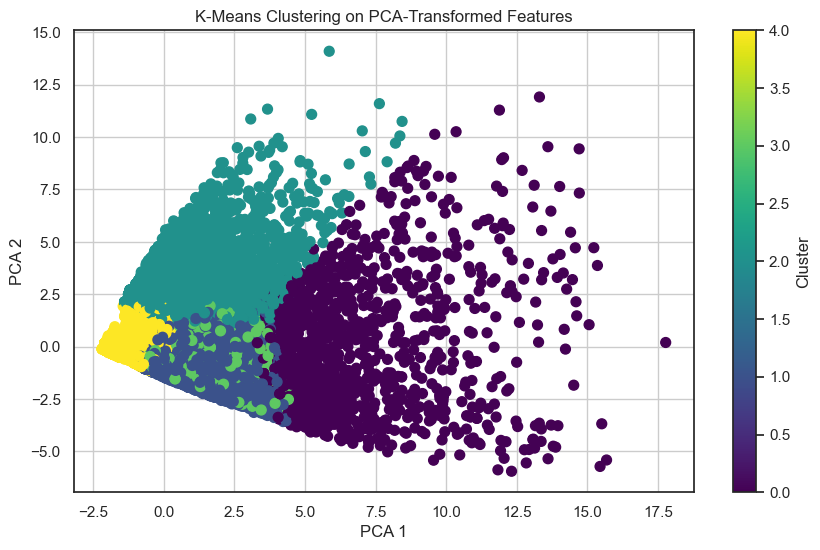

In [22]:
if optimal_n_components == 9:
    plt.figure(figsize=(10, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title('K-Means Clustering on PCA-Transformed Features')
    plt.colorbar(label='Cluster')
    plt.grid(True)
    plt.show()

### TASK: Generate course recommendations based on the popular courses in the same cluster

Suppose a user has joined a machine learning group (via clustering algorithm). In the group, he/she finds that the top-3 courses enrolled by all other group members are `Machine Learning for Everyone`, `Machine Learning with Python`, `Machine Learning with Scikit-learn`. Since the user has already completed the `Machine Learning for Everyone` earlier, he/she decides to trust the group members' choices and enroll in other two unselected courses `Machine Learning with Python` and `Machine Learning with Scikit-learn`.

The clustering-based recommender system first groups all users based on their profiles, and maintains a popular courses list for each group.


In [23]:
test_users_df = pd.read_csv("ratings.csv")[['user', 'item']]
test_users_df.head(2)

,user,item
0,1889878,CC0101EN
1,1342067,CL0101EN


In [26]:
test_users_labelled = pd.merge(test_users_df, final_df, left_on='user', right_on='user')

In [29]:
courses_cluster = test_users_labelled[['item', 'cluster']]
courses_cluster.head(2)

,item,cluster
0,CC0101EN,0
1,CL0101EN,3


In [30]:
# Adding a new column 'count' with a value of 1 for each row in the courses_cluster DataFrame
courses_cluster['count'] = [1] * len(courses_cluster)

C:\Users\user\AppData\Local\Temp\ipykernel_11400\548873436.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  courses_cluster['count'] = [1] * len(courses_cluster)


In [31]:
# Grouping the DataFrame by 'cluster' and 'item', aggregating the 'count' column with the sum function,
# and resetting the index to make the result more readable
courses_cluster_grouped = courses_cluster.groupby(['cluster','item']).agg(enrollments=('count','sum')).reset_index()

_TODO: For each test user, try to recommend any unseen courses based on the popular courses in his/her cluster. You may use an enrollment count threshold (such as larger than 10) to determine if it is a popular course in the cluster_ 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load datasets
profile_df = pd.read_csv("user_profile.csv")
ratings_df = pd.read_csv("ratings.csv")

# ===== PCA Transformation =====
X = profile_df.drop(columns=['user'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=14, random_state=42)
explained_var = np.cumsum(pca.fit(X_scaled).explained_variance_ratio_)
optimal_n = np.argmax(explained_var >= 0.90) + 1

pca_final = PCA(n_components=optimal_n, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

pca_cols = [f'pca_{i+1}' for i in range(optimal_n)]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)
final_df = pd.concat([profile_df[['user']], pca_df], axis=1)

# ===== KMeans Clustering =====
kmeans = KMeans(n_clusters=5, random_state=42)
final_df['cluster'] = kmeans.fit_predict(X_pca)

# ===== Prepare Ratings Data =====
test_users_df = ratings_df[['user', 'item']].drop_duplicates()

# Merge user clusters
test_users_labelled = pd.merge(test_users_df, final_df[['user', 'cluster']], on='user')

# Group course enrollments by cluster
courses_cluster = test_users_labelled[['item', 'cluster']].copy()
courses_cluster['count'] = 1
courses_cluster_grouped = courses_cluster.groupby(['cluster', 'item']).agg(
    enrollments=('count', 'sum')
).reset_index()

# ===== Course Recommendations =====
popularity_threshold = 100
popular_courses_per_cluster = courses_cluster_grouped[
    courses_cluster_grouped['enrollments'] > popularity_threshold
]

user_recommendations = {}

for user in test_users_labelled['user'].unique():
    user_cluster = test_users_labelled.loc[test_users_labelled['user'] == user, 'cluster'].iloc[0]
    user_courses = set(test_users_labelled.loc[test_users_labelled['user'] == user, 'item'])
    
    popular_courses = set(
        popular_courses_per_cluster.loc[popular_courses_per_cluster['cluster'] == user_cluster, 'item']
    )
    
    recommended = list(popular_courses - user_courses)
    user_recommendations[user] = recommended

# Convert to DataFrame
recommendation_df = pd.DataFrame(list(user_recommendations.items()), columns=['user', 'recommended_courses'])

# Display (if in notebook)
print(recommendation_df.head())


      user                                recommended_courses
0  1889878  [BD0212EN, DJ0101EN, ML0120EN, LB0107ENv1, LB0...
1  1342067  [BD0212EN, ML0120EN, SC0103EN, CC0103EN, DV015...
2  1990814  [DJ0101EN, ML0120EN, LB0107ENv1, LB0101ENv1, C...
3   380098  [BD0212EN, DJ0101EN, ML0120EN, LB0107ENv1, LB0...
4   779563  [BD0212EN, DJ0101EN, ML0120EN, DS0110EN, CC010...


On average, how many new/unseen courses have been recommended to each user?

In [34]:
# Compute how many recommendations each user received
recommendation_df['num_recommendations'] = recommendation_df['recommended_courses'].apply(len)

# Compute the average number of new/unseen recommended courses
average_recommendations = recommendation_df['num_recommendations'].mean()

print(f"Average number of new/unseen courses recommended per user: {average_recommendations:.2f}")


Average number of new/unseen courses recommended per user: 48.79


In [35]:
from collections import Counter

# Flatten all recommended courses into a single list
all_recommended_courses = sum(recommendation_df['recommended_courses'], [])

# Count frequency of each course
course_counts = Counter(all_recommended_courses)

# Get top-10 most recommended courses
top_10_courses = course_counts.most_common(10)

# Convert to DataFrame for better readability
top_10_df = pd.DataFrame(top_10_courses, columns=['course', 'times_recommended'])

print("Top 10 Most Frequently Recommended Courses:")
print(top_10_df)


📚 Top 10 Most Frequently Recommended Courses:
       course  times_recommended
0    TA0105EN              32834
1    DS0321EN              32761
2    SC0105EN              32707
3    DB0151EN              32342
4    ML0151EN              31721
5    WA0101EN              31654
6    CC0201EN              31580
7  ML0120ENv2              31336
8    PA0101EN              31300
9    SC0101EN              31180
